<img src="images/banner.png" style="width: 100%;">

# Convolutional Neural Networks (CNN)

**MSDS 2026 | COSCI223: Machine Learning 3**

*Prepared by Kristine Ann M. Carandang*

**Convolutional networks (ConvNets)** or **convolutional neural networks (CNNs)** are a family of models that were inspired by how the visual cortex of human brain works when recognizing objects.

A ConvNet employs a mathematical operation called **convolution**, a specialized kind of linear operation. Accordingly, ConvNets are simply neural networks that use convolution in at least one of their layers.

Convolution layers learn local patterns, giving CNNs two interesting properties:

1. *The patterns they learn are **translation invariant**,* making ConvNets data efficient when processing images becasue the visual world is fundamentally translation invaariant.
    - They need fewer training samples to learn representations that have generalization power.
2. *They can learn **spatial hierarchies** of patterns,* allowing ConvNets efficiently learn increasingly complex and abstract visual concepts because the visual world is fundamentally spatially hierarchical.

<img src="images/spatial-hierarchy.png" style="width: 100%;">
Source: Deep Learning with Python (Chollet & Chollet, 2026)

CNN is the type of deep learning model that is used by most computer vision applications.

- First Application
    > [Backpropagation Applied to Handwritten Zip Code Recognition](http://yann.lecun.com/exdb/publis/pdf/lecun-89e.pdf) (LeCun et al., 1989)


- Current Applications
    1. **Classification** of images, sometimes called *image recognition*
    2. **Detection** of objects in an image and determining their locations within the image
    3. **Segmentation** of images, in which each pixel is classified individually thereby dividing the image into regions sharing a common label
    4. **Caption generation** in which a textual description is generated automatically from an image
    5. **Synthesis** of new images, such as image generation of synthesizing based on a text input describing the desired image content
    6. **Inpainting** in which a region of an image is replaced with synthesized pixels that are consistent with the rest of the image. 
    7. **Style transfer** in which an input image in one style, for example a photograph, is transformed into a corresponding image in a different style, for example an oil painting.
    8. **Super-resolution** in which the resolution of an image is improved by increasing the number of pixels and synthesizing associated high-frequency information.
    9. **Depth prediction** in which one or more views are used to predict the distance of the scene from the camera at each pixel in a target image.
    10. **Scene reconstruction** in which one or more two-dimensional images of a scene are used to reconstruct a three-dimensional representation.

In [1]:
import keras
from keras import layers
from keras.models import Sequential
from keras import models

import numpy as np
import pandas as pd
from matplotlib import rcParams
import matplotlib.pyplot as plt


# Some preambles for prettification
rcParams.update({'figure.figsize': (8, 6), 'axes.spines.top': False,
                 'axes.spines.right': False, 'axes.labelsize': 12,
                 'axes.titlesize': 12, 'axes.titleweight': 'bold',
                 'lines.linewidth': 3})

# Building Blocks of CNNs

As you can see in the following image, a CNN computes feature maps from an input image, where each element comes from a local patch of pixels in the input image:

<img width="919" alt="CNN_dog" src="https://user-images.githubusercontent.com/25600601/134186781-c3eb2e95-fcce-4f65-8f86-60317bfa11d7.png">


CNNs perform very well for image-related tasks, and that's largely due to two important ideas:     

- **Sparse-connectivity:** A single element in the feature map is connected to only a small patch of pixels. (This is very different from connecting to the whole input image, in the case of perceptrons. You may find it useful to look back and compare how we implemented a fully connected network that connected to the whole image.)    

- **Parameter-sharing:** The same weights are used for different patches of the input image. As a direct consequence of these two ideas, the number of weights (parameters) in the network decreases dramatically, and we see an improvement in the ability to capture salient features. Intuitively, it makes sense that *nearby pixels are probably more relevant to each other* than pixels that are far away from each other.

Typically, CNNs are composed of *several Convolution (Conv)* layers and *subsampling (also known as Pooling (P))* layers that are followed by one or more Fully Connected (FC) layers at the end. The fully connected layers are essentially a multilayer perceptron, where every input unit $i$ is connected to every output unit $j$ with weight $w_{ij}$.

## The convolution operation

The **`convolution operation`** extracts patches from its `input feature map` and applies the same transformation to all of these patches, producing an `output feature map`.

These **feature maps** have two spatial axes (`height` and `width`) as well as a `depth` axis (also called the `channels` axis). 
- `input depth`: 1 for black-and-white images, 3 for an RGB image
- `output depth`: can be arbitrary because the output depth is a parameter of the layer, and the different channels in that depth axis stand for *`filters`*
- `filters`: encode specific aspects of the input data
- `response map` of the filter over the input, indicating the response of a filter pattern at different locations in the input

Convolutions are defined by **two key parameters**:

1. *Size of the patches (`window_height`, `window_width`) extracted from the inputs*, typically $3x3$ or $5x5$
2. *Depth of the output feature map*,  the number of filters computed by the convolution

A convolution works by sliding these windows over the input feature map (`height`, `width`, `input_depth`), stopping at every possible location, and extracting the patch of surrounding features of shape (`window_height`, `window_width`, `input_depth`). Each patch is then transformed into a 1D vector of shape (`output_depth`), which is done via a tensor product with a learned weight matrix, called **convolution kernel**. The same kernel is reused across every patch. 

All of these vectors (one per patch) are then spatially reassembled into an output feature map (`height`, `width`, `output_depth`). Every spatial location in the output feature map corresponds to the same location in the input feature map.

Note that the output width and height may differ from the input width and height for two reasons:
- boarder effects
- use of strides

#### Padding (p)
- to pad the edges of the inputs with new values and proceed as usual to retain the input shape

#### Stride (s)
- the distance between two successive windows

### The size of the convolution output

The output size of a convolution is determined by the total  number of times that we shift the filter  $\mathbf{w}$  along the input vector. Again, if the input vector $\mathbf{x}$ has size
$n$ and the filter  $\mathbf{w}$ is of size $m$. Then, the size of the output resulting from  $\mathbf{x} *  \mathbf{w}$  with padding $p$ and stride $s$ is determined as follows:

\begin{equation}
o=floor (\frac{n + 2p - m}{s}) + 1
\end{equation}

Here, the floor operation returns the largest integer that is equal or smaller to the input, e.g. floor (1.43) =1



Consider the following example:

  • Compute the output size for an input vector of size 10 with a convolution kernel of size 5, padding 2, and stride 1:
    
\begin{equation}
n=10, m=5, p=2, s=1, \Rightarrow o= floor(\frac{10+ 2 \times 2 -5}{1}) + 1 = 10
\end{equation}

(Note that in this case, the output size turns out to be the same as the input; therefore, we conclude this as **mode='same' **)

See illustration below if you want to trace it perfectly:

![CNN_Convolution_Example1](https://user-images.githubusercontent.com/25600601/134187810-ed86251d-ddef-45d0-ae1d-62ff80c7d56b.png)


### Performing discrete convolutions in 1D

Let's start with some basic definitions and notations we are going to use. A discrete convolution for two one-dimensional vectors $\mathbf{x}$ and $\mathbf{w}$ is denoted by $\mathbf{y}= \mathbf{x}*\mathbf{w}$ , in which vector $\mathbf{x}$ is our input (sometimes called signal) and $\mathbf{w}$ is called the filter or kernel. A discrete convolution is mathematically defined as follows:   

\begin{equation}
\mathbf{y}= \mathbf{x} * \mathbf{w} = \sum_{k=-\infty}^{k=+\infty} \mathbf{x} [i-k] \mathbf{w}[k]
\end{equation}

Here, the brackets [...] are used to denote the indexing for vector elements. The index $i$ runs through each element of the output vector $\mathbf{y}$. There are two odd things in the preceding formula that we need to clarify: $−\infty$ to $+\infty$ indices and negative indexing for $\mathbf{x}$.

The **first issue** where the **sum runs through indices from $−\infty$ to $+\infty$** seems odd mainly because in machine learning applications, we always deal with finite feature vectors. For example, if $\mathbf{x}$ has 10 features with indices 0,1,2,…,8,9, then indices $−\infty:-1$ and $10 : +\infty$ are out of bounds for $\mathbf{x}$. Therefore, to correctly compute the summation shown in the preceding formula, it is assumed that $\mathbf{x}$ and $\mathbf{w}$ are filled with zeros. This will result in an output vector $\mathbf{y}$ that also has infinite size with lots of zeros as well. Since this is not useful in practical situations, $\mathbf{x}$ is padded only with a
finite number of zeros.   

This process is called **zero-padding** or simply **padding**. Here, the number of zeros padded on each side is denoted by *p*. An example padding of a one-dimensional vector $\mathbf{x}$ is shown in the following figure:

<img width="670" alt="zero-padding" src="https://user-images.githubusercontent.com/25600601/134187112-666edbe5-6e2f-4982-b01b-721ae3f53969.png">


Let's assume that the original input $\mathbf{x}$ and filter $\mathbf{w}$ have $n$ and $m$ elements, respectively, where $m \leq n$. Therefore, the padded vector $\mathbf{x}^p$  has size $n + 2p$. Then, the practical formula for computing a discrete convolution will change to the following:


\begin{equation}
\mathbf{y}= \mathbf{x} * \mathbf{w} \Rightarrow \mathbf{y}[i]= \sum_{k=0}^{k=m-1} \mathbf{x}^p [i+m-k] \mathbf{w}[k]
\end{equation}


Now that we have solved the infinite index issue, the second issue is indexing $\mathbf{x}$ with $i + m - k$. The important point to notice here is that $\mathbf{x}$ and $\mathbf{w}$ are indexed in different directions in this summation. For this reason, we can flip one of those vectors, $\mathbf{x}$ or $\mathbf{w}$, after they are padded. Then, we can simply compute their dot product.    

Let's assume we flip the filter $\mathbf{w}$ to get the rotated filter $\mathbf{w}^r$ . Then, the dot product $\mathbf{x}[i : i + m]$ $\cdot$ $\mathbf{w}^r$ is computed to get one element $\mathbf{y}[i]$, where $\mathbf{x}[i : i + m]$ is a patch of $\mathbf{x}$ with size $m$.

This operation is repeated like in a sliding window approach to get all the output elements. The following figure provides an example with $\mathbf{x} = (3,2,1,7,1,2,5,4)$ and $\mathbf{w}$ = ($\frac{1}{2}, \frac{3}{4}, 1, \frac{1}{4}$) so that the first three output elements are computed:

<img width="738" alt="padding_illustration" src="https://user-images.githubusercontent.com/25600601/134187244-781c5e5e-064a-4194-8ea8-be13285e41fb.png">

You can see in the preceding example that the padding size is zero ($p = 0$). Notice that the rotated filter wr is shifted by two cells each time we shift. This shift is another hyperparameter of a convolution, the stride $s$. In this example, the **stride is two**, $s = 2$. Note that the stride has to be a positive number smaller than the size of the input vector $\mathbf{x}$ (pause and answer why?). We'll talk more about padding and strides in the next section!

#### Exploration Task 1

In order to learn how to compute convolutions in one dimension, a naive implementation is shown in the following code block, and the results are compared with the numpy.convolve function. The code is given below:

In [2]:
def conv1d(x, w, p, s=1):
    w_rot = np.array(w[::-1])
    x_padded = np.array(x)
    if p > 0:
        zero_pad = np.zeros(shape=p)
        x_padded = np.concatenate([zero_pad, x_padded, zero_pad])
    res = []
    for i in range(0, int(len(x)/s),s):
        res.append(np.sum(x_padded[i:i+w_rot.shape[0]] * w_rot))
    return np.array(res)

**Example**

In [3]:
x = [1, 3, 2, 4, 5, 6, 1, 3]
w = [1, 0, 3, 1, 2]

In [4]:
print('Conv1d Implementation:', conv1d(x, w, p=2, s=1))

Conv1d Implementation: [ 5. 14. 16. 26. 24. 34. 19. 22.]


In [5]:
print('Numpy Results:', np.convolve(x, w, mode='same'))

Numpy Results: [ 5 14 16 26 24 34 19 22]


<div class="alert alert-block alert-info"> 
<b>INSTRUCTION</b>
<br>
Create a 1-D array and a filter. Perform the convolution operation.
<br>
</div>

### Performing discrete convolutions in 2D

The concepts you learned in the previous sections are easily extendible to two dimensions. When we deal with two dimensional input, such as a matrix $\mathbf{X}_{n1×n2}$ and the filter matrix $\mathbf{W}_{m1×m2}$, where $m_1 \leq n_1$ and $m_2 \leq n_2$ , then the matrix $\mathbf{Y}$ = $\mathbf{X} * \mathbf{W}$ is the result of 2D convolution of $\mathbf{X}$ with $\mathbf{W}$. This is mathematically defined as follows:


\begin{equation}
\mathbf{Y}= \mathbf{X} * \mathbf{W} \Rightarrow \mathbf{Y}[i, j]= \sum_{k_1=-\infty}^{k_2=\infty}\sum_{k_2=-\infty}^{\infty} \mathbf{X} [i-k_1, j-k_2] \mathbf{W}[k_1, k_2]
\end{equation}

Notice that if you omit one of the dimensions, the remaining formula is exactly the same as the one we used previously to compute the convolution in 1D. In fact, all the previously mentioned techniques, such as zero-padding, rotating the filter matrix, and the use of strides, are also applicable to 2D convolutions, provided that they are extended to both the dimensions independently. The following example illustrates the computation of a 2D convolution between an input matrix $\mathbf{X}_{3×3}$, a kernel matrix $\mathbf{W}_{3×3}$, padding $p = (1, 1)$, and stride $s = (2, 2)$. According to the specified padding, one layer of zeros are padded on each side of the input matrix, which results in the padded matrix $\mathbf{X}_{5×5}^{padded}$, as follows:

<img width="746" alt="padded_2d" src="https://user-images.githubusercontent.com/25600601/134188176-c6a412b6-c6bd-49a4-bbdd-508b285e0882.png">

With the preceding filter, the rotated filter will be:

<img width="373" alt="Wrotated" src="https://user-images.githubusercontent.com/25600601/134188347-20df516d-0292-430a-91d5-bcc9eebc366e.png">

Note that this rotation is not the same as the transpose matrix. To get the rotated filter in NumPy, we can write W_rot=W[::-1,::-1]. Next, we can shift the rotated filter matrix along the padded input matrix $\mathbf{X}$ padded like a sliding window and compute the sum of the element-wise product, which is denoted by the dot operator in the
following figure:

<img width="900" alt="2d_convolution" src="https://user-images.githubusercontent.com/25600601/134188450-7da6a7f4-cea5-4b0d-80cd-34b56d3804ee.png">

The result will be the $2 \times 2$ matrix $\mathbf{Y}$.    

## The CNN architecture

A model’s “architecture” is the sum of the choices that went into creating it: which layers to use, how to configure them, in what arrangement to connect them. 

<img width="704" alt="CNN_full" src="https://user-images.githubusercontent.com/25600601/134190140-22451833-879f-4696-b365-7eb22dcd3933.png">

### The modularity-hierarchy-reuse formula

The CNN model should be organized into repeated **`blocks`** of layers, usually made of multiple convolution layers and a max pooling layer. The number of filters in the layers should increase as the size of the spatial feature maps decreases.
- The width and height dimensions tend to shrink as you go deeper in the model.
- The number of channels is controlled by the first argument passed to the convulation layer.

This formula underpins the architecture of nearly all complex systems, including deep learning models. 

### Convolution layers
- **`Conv1D`**: [1D convolution layer](https://keras.io/api/layers/convolution_layers/convolution1d/)
    - sequential signals or text data
- **`Conv2D`**:[2D convolution layer](https://keras.io/api/layers/convolution_layers/convolution2d/)
    - images, time-frequency representations (speech and audio)
- **`Conv3D`**:[3D convolution layer](https://keras.io/api/layers/convolution_layers/convolution3d/)
- [Other convolution layers](https://keras.io/api/layers/convolution_layers/)
    - video, volumetric images, tomography images

#### Sample Dataset

We will use the MNIST dataset in this notebook, and in the associated exercise.

In [6]:
# Load dataset
(x_trainval, y_trainval), (x_test, y_test) = keras.datasets.mnist.load_data()

In [7]:
x_trainval[417].shape

(28, 28)

In [8]:
y_trainval[417]

np.uint8(5)

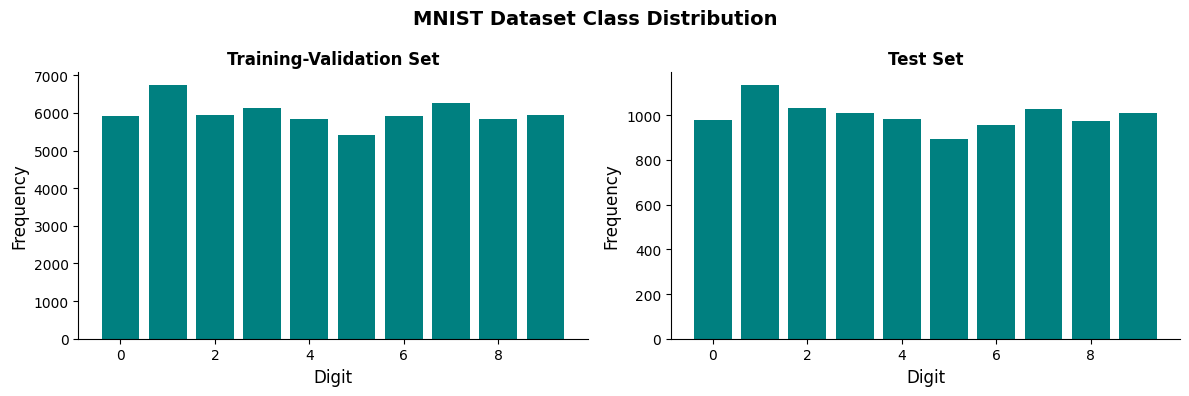

In [9]:
# Plot class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

plt.suptitle('MNIST Dataset Class Distribution',
             fontweight='bold', fontsize=14)

# Check class distribution for trainval set
unique, counts = np.unique(y_trainval, return_counts=True)
for digit, count in zip(unique, counts):
    # print(f"Digit {digit}: {count}")
    ax1.bar(unique, counts, color='teal')
    ax1.set_xlabel("Digit")
    ax1.set_ylabel("Frequency")
    ax1.set_title("Training-Validation Set", fontsize=12)

# Check class distribution for test set
unique, counts = np.unique(y_test, return_counts=True)
for digit, count in zip(unique, counts):
    # print(f"Digit {digit}: {count}")
    ax2.bar(unique, counts, color='teal')
    ax2.set_xlabel("Digit")
    ax2.set_ylabel("Frequency")
    ax2.set_title("Test Set", fontsize=12)

plt.tight_layout()

**Example**
  
Here, we apply a 2D convolution layer with one (1) 3x3 filter to a sample image from the MNIST dataset, visualize the feature maps, the **convolution kernel** (learned weight matrix).

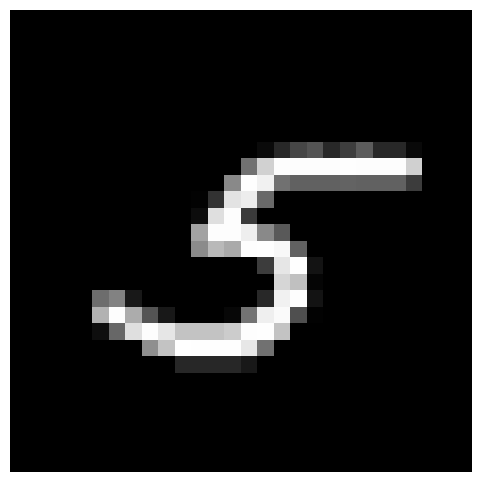

In [10]:
# Display a sample image
sample = x_trainval[417]
plt.imshow(sample, cmap='gray');
plt.axis('off');

In [11]:
# Normalize
sample = sample.astype("float32") / 255.0

In [12]:
# Check the dimensions of the input
sample.shape

(28, 28)

Note that the **`input_shape`** in Keras follows the following syntax: 
- (`batch_size`, `height`, `width`, `channels`)

In [13]:
# Reshape to (1, 28, 28, 1) - batch size, height, width, channels
img = np.expand_dims(sample, axis=(0, -1))
img.shape

(1, 28, 28, 1)

In [14]:
# Define a Conv2D layer with 1 3x3 filter
model = Sequential([
    layers.Input(shape=(28,28,1)),
    layers. Conv2D(1, (3, 3), activation="relu") # kernel Settings
])

# Apply a convolution
feature_map = model.predict(img)

print("Input shape:", img.shape)
print("Output shape:", feature_map.shape)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Input shape: (1, 28, 28, 1)
Output shape: (1, 26, 26, 1)


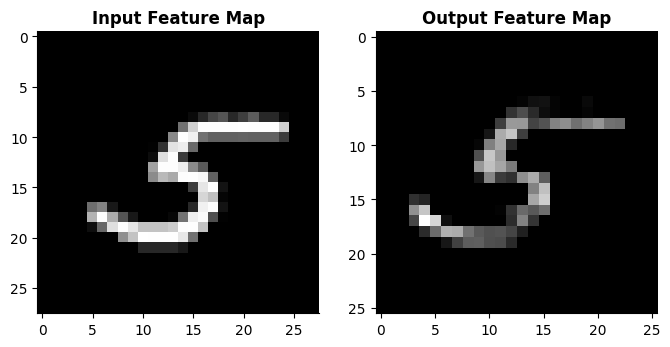

In [15]:
# Display input feature map
plt.subplot(1, 2, 1)
plt.title("Input Feature Map")
plt.imshow(img[0, :, :, 0], cmap="gray")

# Display output feature map
plt.subplot(1, 2, 2)
plt.title("Output Feature Map")
plt.imshow(feature_map[0, :, :, 0], cmap="gray")

plt.show()

In [16]:
# Get the weights from the Conv2D layer
weights, bias = model.layers[0].get_weights()

print("Weights shape:", weights.shape)
print("Bias shape:", bias.shape)

Weights shape: (3, 3, 1, 1)
Bias shape: (1,)


- weights shape → (3, 3, 1, 1)
    - kernel height = 3
    - kernel width = 3
    - input channels = 1
    - number of filters = 1
- bias shape → (1,)

In [17]:
# Get the actual kernel values
kernel = weights[:, :, 0, 0]
print(kernel)

[[-0.50468206  0.35952425 -0.3368713 ]
 [-0.22924346  0.38092667  0.5578923 ]
 [-0.4801945  -0.19624823  0.43837798]]


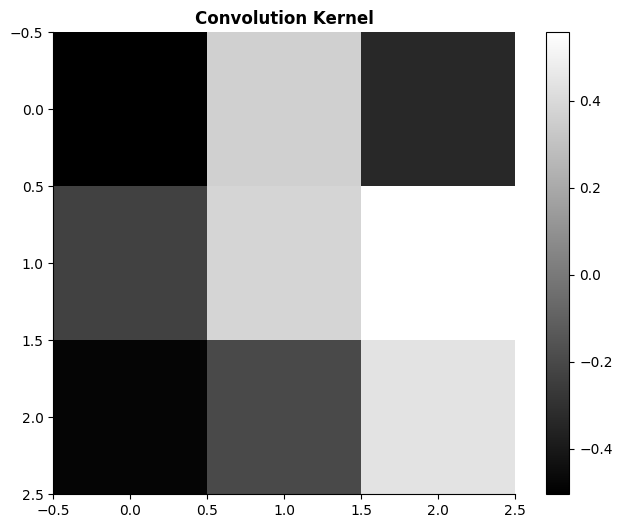

In [18]:
# Display the convolution kernel
plt.imshow(kernel, cmap="gray")
plt.title("Convolution Kernel")
plt.colorbar()
plt.show()

#### Exploration Task 2

<div class="alert alert-block alert-info"> 
<b>INSTRUCTIONS</b>
<br>
Apply a 2D convolution layer with <b>four (4)</b> 3x3 filters to the same sample image (stored as <b>`img`</b>), visualize the feature maps, and the convolution kernels. 
<br>1. Define a Conv2D layer with 4 3x3 filters
<br>2. Apply a convolution 
<br>3. Display the input feature maps
<br>4. Get the weights from the Conv2D layer
<br>5. Visualize the four convolution kernels
<br>6. Adding an activation layer
<br>7. Visualize the four output feature maps
<br>
</div>

In [19]:
# Define a Conv2D layer with 4 3x3 filters
# 1) Define Conv2D with four 3x3 filters
# model = Sequential([
#     layers.Input(shape=(28, 28, 1)),
#     layers.Conv2D(4, (3, 3), padding="same", activation=None, name="conv4")
# ])
model = Sequential([
    layers.Input(shape=(28, 28, 1)),
    # Conv2D layer with 4 3x3 filters
    layers.Conv2D(4, (3, 3), padding="same", activation="relu", name="conv4")
])

In [20]:
# Apply a convolution
# 2) Apply convolution
feature_maps = model.predict(img, verbose=0)
print("Input shape :", img.shape)
print("Conv output :", feature_maps.shape)


Input shape : (1, 28, 28, 1)
Conv output : (1, 28, 28, 4)


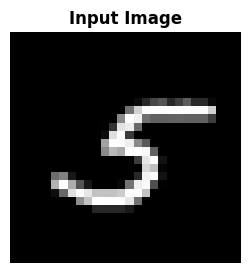

In [21]:
# Display the input feature maps# 3) Display input feature map
plt.figure(figsize=(3,3))
plt.imshow(img[0, :, :, 0], cmap="gray")
plt.title("Input Image")
plt.axis("off")
plt.show()

In [22]:
# Get the weights from the Conv2D layer
# 4) Get weights from Conv2D layer
weights, bias = model.layers[0].get_weights()
print("Weights shape:", weights.shape)  # (3,3,1,4)
print("Bias shape:", bias.shape)        # (4,)

Weights shape: (3, 3, 1, 4)
Bias shape: (4,)


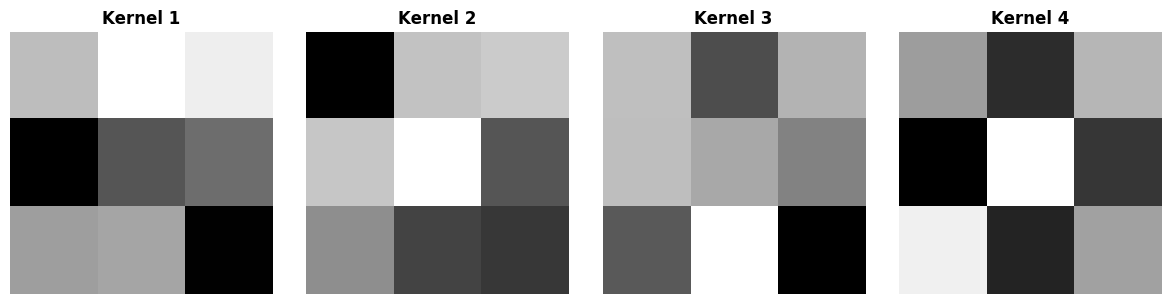

In [23]:
# Visualize the four convolution kernels
# 5) Visualize four convolution kernels
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(weights[:, :, 0, i], cmap="gray")
    axes[i].set_title(f"Kernel {i+1}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

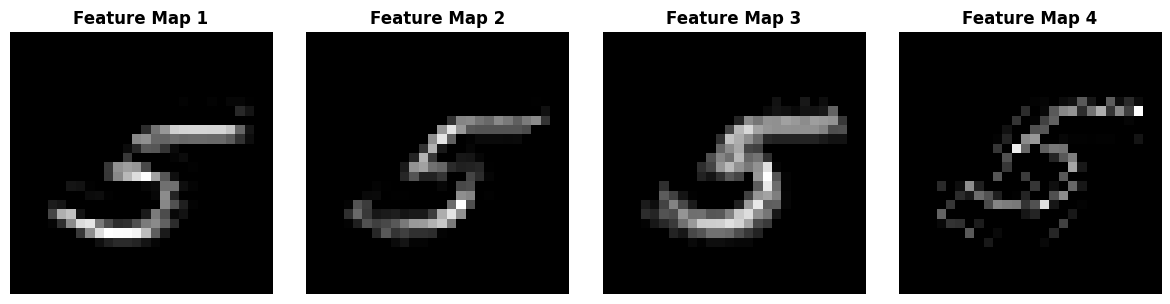

In [24]:
# # Visualize the four output feature maps
# 7) Visualize four output feature maps
# (Conv2D already uses activation="relu", so no separate ReLU model needed)
feature_maps = model.predict(img, verbose=0)
# feature_map = model.predict(img)
# 
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    axes[i].imshow(feature_maps[0, :, :, i], cmap='gray')
    axes[i].set_title(f"Feature Map {i+1}")
    axes[i].axis("off")
plt.tight_layout()
plt.show()

### Pooling layer

This replaces the output of the net at a certain location with a summary statistic of the nearby outputs.

- https://keras.io/api/layers/pooling_layers/

### Other Layers

#### Batch Normalization

This applies a transformation that maintains the mean output close to 0 and the output standard deviation close to 1. 

- https://keras.io/api/layers/normalization_layers/batch_normalization/

#### Dropout Layer

This randomly sets input units to 0 with a frequency of rate at each step during training time, which helps prevent overfitting.

- https://keras.io/api/layers/regularization_layers/dropout/

#### Fully connected layers
These layers are stacks of dense layers that serve as the classifier.
- https://keras.io/api/layers/core_layers/dense/

### Principles

- Your model should be organized into repeated **`blocks`** of layers, usually made of multiple convolution layers and a max pooling layer.
- The number of filters in your layers should increase as the size of the spatial feature maps decreases.
- Deep and narrow is better than broad and shallow.
- By default each feature map has a bias inherently added in Keras.
- Introducing *`residual connections`* around blocks of layers helps you train deeper networks. 
- It can be beneficial to introduce *`batch normalization`* layers after your convolution layers.
- It can be beneficial to replace *`Conv2D`* layers with *`SeparableConv2D`* layers, which are more parameter efficient.

#### Exploration Task 3

<div class="alert alert-block alert-info"> 
<b>INSTRUCTIONS</b>
<br>
Perform the following operations:
<br>1. Altering Conv2D layer parameters
<br>1.1. stride > 1
<br>1.2. padding > 0
<br>1.3. dilation > 3
<br>2. Adding a maxpooling layer 
<br>3. Adding a batch normalization layer
<br>4. Adding a dropout layer
<br>5. Adding a dense layer
<br>6. Using a SeparableConv2D layer instead of Conv2D
<br>
<br>
<b>GUIDE QUESTIONS</b>
<li> What happens when stride, padding or dilation of the Conv2d layer are not set to default?
<li> For each layer/operation, note what happens to the shape and the number of parameters.
</div>

Layer setting up

In [25]:
import numpy as np
from tensorflow.keras import Sequential, layers

# Assume img already exists with shape (1, 28, 28, 1)
# Example:
# img = np.expand_dims(x_trainval[0].astype("float32")/255.0, axis=(0, -1))

def inspect_model(model, name):
    print(f"\n=== {name} ===")
    model.summary()
    y = model.predict(img, verbose=0)
    print("Input shape :", img.shape)
    print("Output shape:", y.shape)

# 1.1 stride > 1
m_stride = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(4, (3, 3), strides=2, padding="valid", activation="relu"),
    layers.AveragePooling2D((2, 2)), # For Class Activity
])
inspect_model(m_stride, "Conv2D with strides=2")

# 1.2 padding > 0 (via 'same', equivalent to automatic zero padding for 3x3)
m_padding = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(4, (3, 3), padding="same", activation="relu"),
    # layers.AveragePooling2D((2, 2)), # For Class Activity
])
inspect_model(m_padding, "Conv2D with padding='same'")

# 1.3 dilation > 3
# Note: In Keras, Conv2D does NOT allow strides>1 together with dilation_rate>1.
m_dilation = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(4, (3, 3), dilation_rate=4, padding="valid", activation="relu"),
    layers.AveragePooling2D((2, 2)), # For Class Activity
])
inspect_model(m_dilation, "Conv2D with dilation_rate=4")

# 2-6 combined pipeline (using SeparableConv2D instead of Conv2D)
m_full = Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.SeparableConv2D(4, (3, 3), padding="valid", activation="relu"),  # 6
    layers.MaxPooling2D((2, 2)),                                           # 2
    layers.BatchNormalization(),                                            # 3
    layers.Dropout(0.25),                                                   # 4
    layers.Flatten(),
    layers.Dense(32, activation="relu"),                                   # 5
    layers.Dense(10, activation="softmax")
])
inspect_model(m_full, "SeparableConv2D + Pool + BN + Dropout + Dense")



=== Conv2D with strides=2 ===


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 4)      │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 6, 6, 4)        │             0 │
│ (AveragePooling2D)              │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40 (160.00 B)

 Trainable params: 40 (160.00 B)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ separable_conv2d                │ (None, 26, 26, 4)      │            17 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 13, 13, 4)      │            16 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 4)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 676)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │        21,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,027 (86.04 KB)

 Trainable params: 22,019 (86.01 KB)

 Non-trainable params: 8 (32.00 B)

Input shape : (1, 28, 28, 1)
Output shape: (1, 10)


Creating Function for Plotting Kernels and Feature Maps

In [26]:
def inspect_model(model, name, img):
    import matplotlib.pyplot as plt
    from tensorflow.keras import layers, Model

    print(f"\n=== {name} ===")
    y = model.predict(img, verbose=0)
    print("Input shape :", img.shape)
    print("Output shape:", y.shape)

    first = model.layers[0]
    w = first.get_weights()

    # Show first-layer kernels
    if isinstance(first, layers.Conv2D):
        kernels = w[0]  # (kh, kw, in_ch, out_ch)
        n_filters = kernels.shape[-1]
        fig, axes = plt.subplots(1, n_filters, figsize=(3*n_filters, 3))
        if n_filters == 1: axes = [axes]
        for i in range(n_filters):
            axes[i].imshow(kernels[:, :, 0, i], cmap="gray")
            axes[i].set_title(f"Kernel {i+1}")
            axes[i].axis("off")
        plt.tight_layout(); plt.show()

    elif isinstance(first, layers.SeparableConv2D):
        depthwise = w[0]  # (kh, kw, in_ch, depth_multiplier)
        n_k = depthwise.shape[-1]
        fig, axes = plt.subplots(1, n_k, figsize=(3*n_k, 3))
        if n_k == 1: axes = [axes]
        for i in range(n_k):
            axes[i].imshow(depthwise[:, :, 0, i], cmap="gray")
            axes[i].set_title(f"Depthwise K{i+1}")
            axes[i].axis("off")
        plt.tight_layout(); plt.show()

    # Show feature maps if 4D output, else show class scores
    if y.ndim == 4:
        n_maps = y.shape[-1]
        fig, axes = plt.subplots(1, n_maps, figsize=(3*n_maps, 3))
        if n_maps == 1: axes = [axes]
        for i in range(n_maps):
            axes[i].imshow(y[0, :, :, i], cmap="gray")
            axes[i].set_title(f"Feature {i+1}")
            axes[i].axis("off")
        plt.tight_layout(); plt.show()
    else:
        print("Final output is not a feature map (likely Dense output):")
        print(y[0])



=== Conv2D with padding='same' ===
Input shape : (1, 28, 28, 1)
Output shape: (1, 28, 28, 4)


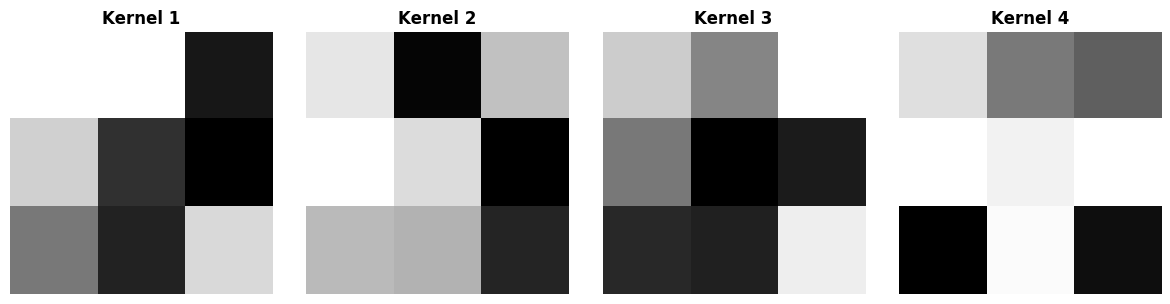

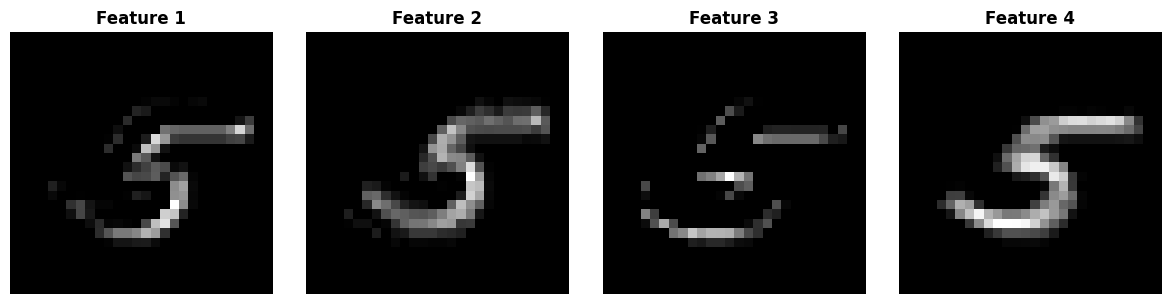


=== Conv2D with strides=2 ===
Input shape : (1, 28, 28, 1)
Output shape: (1, 6, 6, 4)


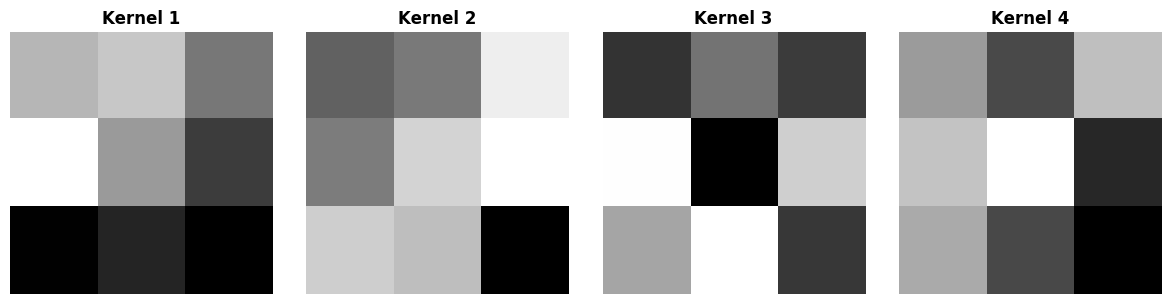

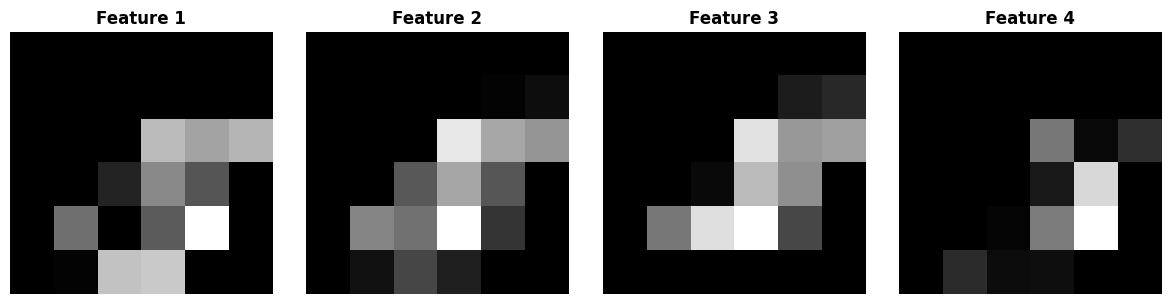


=== Conv2D with dilation_rate=4 ===
Input shape : (1, 28, 28, 1)
Output shape: (1, 10, 10, 4)


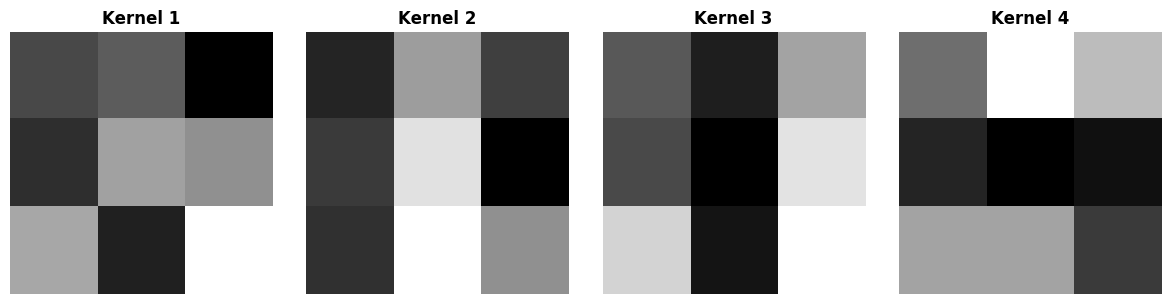

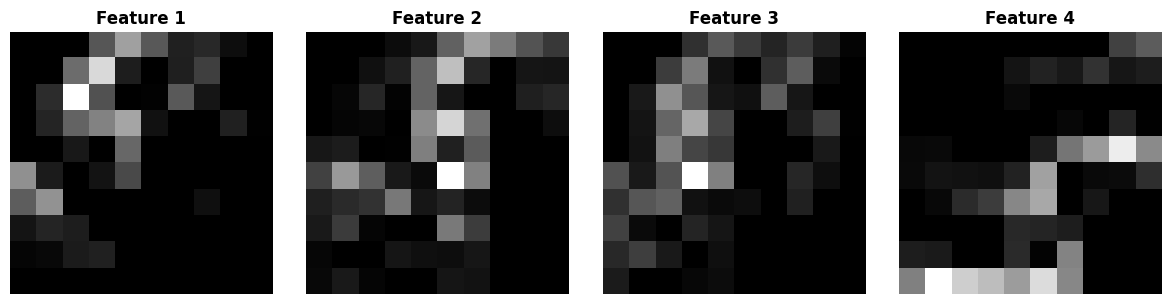

In [27]:
inspect_model(m_padding, "Conv2D with padding='same'", img)
inspect_model(m_stride, "Conv2D with strides=2", img)
inspect_model(m_dilation, "Conv2D with dilation_rate=4", img)
# inspect_model(m_full, "SeparableConv2D + Pool + BN + Dropout + Dense", img)

Viewing SeperableConv2D Results

Feature map shape: (1, 26, 26, 4)


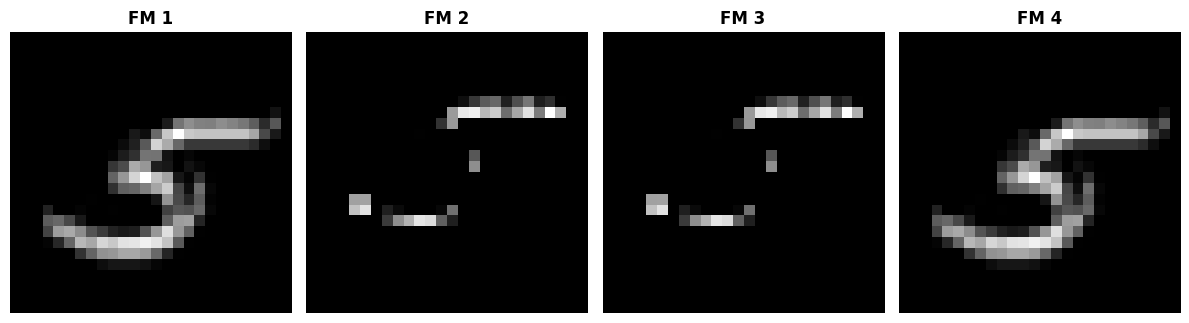

In [28]:
from tensorflow.keras import Model

# 1) Build/call the model first
_ = m_full.predict(img, verbose=0)      # or: _ = m_full(img)

# 2) Create a model that outputs SeparableConv2D feature maps
sep_out_model = Model(inputs=m_full.inputs, outputs=m_full.layers[0].output)

# 3) Get feature maps
fm = sep_out_model.predict(img, verbose=0)
print("Feature map shape:", fm.shape)   # (1, H, W, C)

n_rows, n_cols = 1, 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 6))
axes = axes.ravel()

for i in range(n_rows * n_cols):
    axes[i].imshow(fm[0, :, :, i], cmap="gray")
    axes[i].set_title(f"FM {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Guide Questions**

Conv2D  
- What it is: slides small filters over image to detect patterns (edges, curves, textures).
- Increase filters: learns more pattern types and recurring shapes; more parameters and compute.
- Increase kernel_size: model sees bigger local area; more params and shifts from tiny details to broader local shapes.
- Increase stride (>1): moves filter in bigger steps; output becomes smaller faster (downsampling). : learns coarser pattern placement (less precise location).
- Increase padding: adds border pixels (usually zeros), helps keep edge info and preserve size.
Increase dilation: spreads kernel points apart, sees wider context patterns without increasing kernel param count.

**Effects of Adding Layers**

MaxPooling2D
- What it is: takes max value in each window (e.g., 2x2), shrinking width/height.
- Increase pool size/stride: stronger shrinking, less detail retained. keeps strongest response in a region.  shifts learning toward “feature exists here” instead of exact position.
- Add more pooling layers: faster size reduction, less memory/compute, but too much can lose useful info.
- Typical use: after conv blocks to reduce spatial size.

BatchNormalization
- What it is: normalizes activations per batch, then learns scale/shift.
- Add BN layers: often makes training more stable/faster. reduces internal scale drift.
- Too many BN layers: can add overhead and sometimes reduce benefit depending on model/data size.
- Typical use: after Conv/Dense (often before/after activation depending style).

Dropout
- What it is: randomly turns off some neurons during training. discourages reliance on single neurons/features.
- Increase dropout rate (e.g., 0.2 -> 0.5): stronger regularization, less overfitting, but too high can underfit.
- Add more dropout layers: more regularization, usually in classifier part.
- Typical use: near dense/classifier layers; sometimes between conv blocks.
- Only Applied during Training

Dense
- What it is: fully connected layer for final decision/classification.
- Increase units: more learning capacity, more parameters, higher overfitting risk.
- Add more dense layers: can model complex decision boundaries, but may overfit and train slower.
- Typical use: near model end after Flatten/GlobalAveragePooling.

SeparableConv2D (vs Conv2D)
- Benefit is that it is much fewer parameters and compute than normal Conv2D, often similar accuracy.
- Increase filters: still increases capacity, usually cheaper than standard Conv2D.
- Typical use: lightweight CNNs (mobile/efficient models).



## Model Development

**Major Steps in Model Development**
> 1. Prepare the data.
> 2. Choose a model evaluation protocol.
> 3. Set a baseline.
> 4. Build the initial model.
> 5. Identify the `loss function`, `optimizer` and `metrics` appropriate to the use case.
> 6. Configure the learning process using the `compile()` method.
> 7. Identify the `number of epochs` and the `batch size`.
> 7. Set `callbacks` to perform desired actions at various stages of training (like saving a model or interrupting the training).
> 8. Implement the training loop using `fit()` method.
> 9. Regularize and tune your model until the best possible generalization performance is achieved.

#### Exploration Task 4

<div class="alert alert-block alert-info"> 
<b>INSTRUCTION</b>
<br>
Create an initial model to classify handwritten digits using the MNIST dataset.
</div>

**Step 1. Instantiate a small convnet**

In [48]:
# Instantiate a small CNN model
model = models.Sequential()
# model.add(layers.Input(shape=(28, 28, 1)))
# model.add(layers.Conv2D(32, (3, 3),activation='relu',))
# model.add(layers.MaxPooling2D((2, 2)))
# model.add(layers.Conv2D(64, (3, 3), |activation='relu'))
# model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))


In [49]:
# Display the architecture of the model
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

You can see that the output of every Conv2D and MaxPooling2D layer is a 3D tensor of shape (height, width, channels). The width and height dimensions tend to shrink as you go deeper in the network. The number of channels is controlled by the first argument passed to the Conv2D layers (32 or 64).

Note that the default padding is zero $p=0$ and default stride is 1 $s=1$.

The 320 parameters in the first layer is because each image is convolved to a kernel/filter (weight) equal to (3 $\times$ 3) using 32 feature maps (3 $\times$ 3 $\times$ 32 = 9 $\times$ 32 = 288). Add a bias node for each of kernel in the 32 feature maps (1 $\times$ 32=32), and the total parameters is 288 + 32 = 320.

Max pooling will not add any new parameter but passing it into another 3 $\times$ 3 filter this time producing 64 feature maps for every 32 feature maps previously produce we have a total of  (32 $\times$ 64  $\times$ 3  $\times$ 3 =18,432) parameters. Add to this the bias for each of the 64 feature maps and the total is (18,432 + 64) 18,496. The process continues for the suceeding layers.

**Step 2. Add a classifier on top of the convnet**

The next step is to feed the last output tensor (of shape (3, 3, 64)) into a densely connected classifier network like those you’re already familiar with: a stack of Dense layers. These classifiers process vectors, which are 1D, whereas the current output is a 3D tensor. First we have to flatten the 3D outputs to 1D, and then add a few Dense layers on top.

In [50]:
# Add a classifier on top
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='sigmoid'))

We’ll do 10-way classification, using a final layer with 1 output and a softmax activation.
Here’s what the network looks like now:

In [51]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

As you can see above, the (3, 3, 64) outputs are flattened into vectors of shape (576,) before going through two Dense layers. The total parameters if we use a 64 hidden nodes on the flattened 576 features is (64 $\times$ 576 = 36,864) plus a built in biased in each of the 64 hidden nodes we get 36,928. Another small layer is added that contributes (64 $\times$ 1 + 1 = 65) parameters.

**Step 3. Train the convnet on the MNIST images**

Now, let’s train the convnet on the MNIST digits.

In [52]:
from keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

# # Perform the model completion step
# model.compile(optimizer='rmsprop',
#               loss='categorical_crossentropy',
#               metrics=['accuracy'])

# # Perform model fitting
# model.fit(x_trainval,
#           y_trainval,
#           epochs=5,
#           batch_size=64)

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = train_images.reshape((60000, 28, 28, 1))
train_images = train_images.astype('float32') / 255

test_images = test_images.reshape((10000, 28, 28, 1))
test_images = test_images.astype('float32') / 255

train_labels = to_categorical(train_labels)
test_labels = to_categorical(test_labels)

model.compile(optimizer='rmsprop', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=64)

Epoch 1/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8491 - loss: 0.0910
Epoch 2/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9714 - loss: 0.0223
Epoch 3/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9812 - loss: 0.0152
Epoch 4/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9852 - loss: 0.0123
Epoch 5/5
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9877 - loss: 0.0101


**Step 4. Evaluate the model on the test data.**

In [54]:
# test_loss, test_acc = model.evaluate(x_test, y_test)
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9898 - loss: 0.0062


In [55]:
test_acc, test_loss

(0.989799976348877, 0.0062477788887917995)

Saving Model Baseline

In [56]:
model.save("keras_model_baseline.keras")

Load Model Baseline

In [57]:
from tensorflow import keras
model_base = keras.models.load_model("keras_model_baseline.keras")
# test_loss, test_acc = model_base.evaluate(x_test, y_test)

`test_acc`

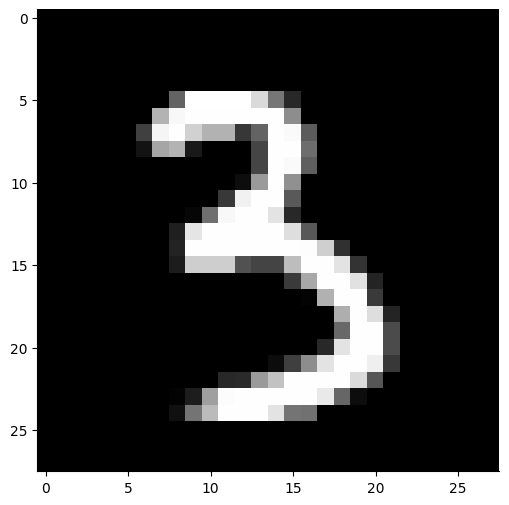

test label = 3
predicted label = 3
predicted probs = [  0.   0.   0. 100.   0.   0.   0.   0.   0.   0.] %
confidence: 100.0


In [64]:
sample_number=32
first_image = x_test[sample_number]
first_image = np.array(first_image, dtype='float')
pixels = first_image.reshape((28, 28))
plt.imshow(pixels, cmap='gray')
plt.show()
print("test label =", y_test[sample_number])

# Make sure shape is (1, 28, 28, 1) before predict
input_image = np.expand_dims(first_image, axis=0)   # add batch dim
if input_image.ndim == 3:                            # if no channel dim yet
    input_image = np.expand_dims(input_image, axis=-1)

pred_probs = model_base.predict(input_image, verbose=0)
pred_label = np.argmax(pred_probs, axis=1)[0]

# print("test label =", y_test[sample_number])
print("predicted label =", pred_label)
print("predicted probs =", pred_probs[0]*100,"%")
digit = int(np.argmax(pred_probs[0]))
confidence = float(pred_probs[0][digit] * 100)
print("confidence:", confidence)

<div class="alert alert-block alert-info"> 
Is this initial implementation correct?
</div>

# Exercise 3: Handwritten Digit Classification

**Instructions**
  
1. Improve the initial model until you obtain your best model. Consider tuning key gradient descent parameters, tuning the representational power of your model by chaning the number and/or type of layers or the size of the layers, or applying regularizations.

2. Report the model performances on the training, validation and test sets of your initial and best models. Describe the steps you undertook to improve the performance of your initial model.

3. Generate your own set of handwritten number images from 0 to 9. Test your best model on this set, and report its performance.

**Please use the exercise notebook to accomplish this task.**

Model Accuracy to Beat

In [65]:
test_acc

0.989799976348877

## Task 1: Building A New Neural Network Layer

In [68]:
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.utils import to_categorical

# Load MNIST
(x_trainval, y_trainval), (x_test, y_test) = keras.datasets.mnist.load_data()

# Preprocess inputs
x_trainval = x_trainval.reshape((60000, 28, 28, 1)).astype("float32") / 255.0
x_test = x_test.reshape((10000, 28, 28, 1)).astype("float32") / 255.0

# One-hot labels for 10 classes
y_trainval = to_categorical(y_trainval, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Rebuild model (important: final layer must be 10-way softmax)
model = models.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")  # fixed
])

model.compile(optimizer="rmsprop", loss="categorical_crossentropy", metrics=["accuracy"])
history = model.fit(x_trainval, y_trainval, epochs=5, batch_size=64, validation_split=0.1)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9042 - loss: 0.3116 - val_accuracy: 0.9812 - val_loss: 0.0628
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9732 - loss: 0.0964 - val_accuracy: 0.9878 - val_loss: 0.0423
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9828 - loss: 0.0641 - val_accuracy: 0.9892 - val_loss: 0.0416
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9852 - loss: 0.0508 - val_accuracy: 0.9890 - val_loss: 0.0440
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9879 - loss: 0.0437 - val_accuracy: 0.9900 - val_loss: 0.0353


Save and Load Model

In [74]:
# Save full model (architecture + weights + optimizer state)
model.save("keras_model.keras") # Rename File To prevent Overwrite 
print("Model saved")

# # Optional: save only weights
# model.save_weights("mnist_cnn_weights.weights.h5")
# print("Weights saved to mnist_cnn_weights.weights.h5")

# # Optional: load back to verify
# loaded_model = keras.models.load_model("mnist_cnn_model.keras")
# loaded_model.summary()


Model saved


### **Hyperparameter Tuning to get Best Model**

Tuning Options (Standard Ranges):
- Learning rate: 1e-4 to 1e-2. The learning rate controls how quickly the model updates weights.
- Optimizer: Adam, RMSprop, SGD+momentum (will stick with Adam to simplify) 
- Batch size: 32, 64, 128. The batch size (not tuned here) controls how many samples the model processes before updating weights.
- Dropout: 0.2–0.6  
- Conv filters: e.g., [32,64], [32,64,128]  
- Dense units: 64, 128, 256  
- Epochs + callbacks: use EarlyStopping. Epochs control how many times the model sees the entire dataset.
- The number of filters controls how many features the CNN extracts.
- The number of units in dense layers controls model capacity.



Optimizers. The algorithm method to update the model weights during training to reduce loss. Common Optimizers Include:
- SGD: simple, stable, may need careful learning-rate tuning
- RMSprop: adapts learning rate per parameter
- **Adam**: most common default; usually converges faster
- AdamW: Adam with decoupled weight decay; often better regularization than plain Adam.
- Adagrad: Larger updates for rare features, smaller for frequent ones; good for sparse data.



In [79]:
# %pip install keras-tuner
# %pip install tensorboard

  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
Using cached tensorboard-2.20.0-py3-none-any.whl (5.5 MB)
Using cached tensorboard_data_server-0.7.2-py3-none-any.whl (2.4 kB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
import keras_tuner as kt
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

def build_model(hp):
    model = models.Sequential()
    model.add(layers.Input(shape=(28, 28, 1)))

    # Block 1
    model.add(layers.Conv2D(
        filters=hp.Choice("filters_1", [16, 32, 48]),
        kernel_size=hp.Choice("kernel_1", [3, 5]),
        activation="relu",
        padding="same"
    ))
    model.add(layers.MaxPooling2D((2, 2)))

    # Block 2
    model.add(layers.Conv2D(
        filters=hp.Choice("filters_2", [32, 64, 96]),
        kernel_size=hp.Choice("kernel_2", [3, 5]),
        activation="relu",
        padding="same"
    ))
    model.add(layers.MaxPooling2D((2, 2)))

    # Optional block 3
    if hp.Boolean("use_block3"):
        model.add(layers.Conv2D(
            filters=hp.Choice("filters_3", [64, 96, 128]),
            kernel_size=3,
            activation="relu",
            padding="same"
        ))

    model.add(layers.Flatten())
    model.add(layers.Dense(
        units=hp.Choice("dense_units", [64, 128, 256]),
        activation="relu"
    ))
    model.add(layers.Dropout(hp.Float("dropout", 0.2, 0.6, step=0.1)))
    model.add(layers.Dense(10, activation="softmax"))

    opt_name = hp.Choice("optimizer", ["adam", "rmsprop"])
    lr = hp.Choice("learning_rate", [1e-2, 1e-3, 5e-4, 1e-4])

    if opt_name == "adam":
        optimizer = keras.optimizers.Adam(learning_rate=lr)
    else:
        optimizer = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

tuner = kt.Hyperband( # improved version of random search
    build_model,
    objective="val_accuracy",
    max_epochs=12,
    factor=3,
    directory="kt_results",
    project_name="mnist_cnn",
    overwrite=True
)

early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)

tuner.search(
    x_trainval, y_trainval,
    validation_split=0.1,
    epochs=12,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

best_hp = tuner.get_best_hyperparameters(1)[0]
print("Best hyperparameters:")
for k in best_hp.values:
    print(f"{k}: {best_hp.get(k)}")

best_model = tuner.get_best_models(1)[0]
test_loss, test_acc = best_model.evaluate(x_test, y_test, verbose=0)
print(f"Best model test accuracy: {test_acc:.4f}")

best_model.save("mnist_cnn_tuned.keras")
print("Saved: mnist_cnn_tuned.keras")

Trial 30 Complete [00h 00m 51s]
val_accuracy: 0.9908333420753479

Best val_accuracy So Far: 0.9933333396911621
Total elapsed time: 00h 15m 06s
Best hyperparameters:
filters_1: 16
kernel_1: 5
filters_2: 64
kernel_2: 5
use_block3: False
dense_units: 256
dropout: 0.5
optimizer: rmsprop
learning_rate: 0.001
filters_3: 64
tuner/epochs: 12
tuner/initial_epoch: 4
tuner/bracket: 2
tuner/round: 2
tuner/trial_id: 0015
Best model test accuracy: 0.9922
Saved: mnist_cnn_tuned.keras


Hyperparameter Best Model
- Best val_accuracy So Far: 0.9933333396911621
- Total elapsed time: 00h 15m 06s
- Best hyperparameters:
- filters_1: 16
- kernel_1: 5
- filters_2: 64
- kernel_2: 5
- use_block3: False
- dense_units: 256
- dropout: 0.5
- optimizer: rmsprop
- learning_rate: 0.001
- filters_3: 64
- tuner/epochs: 12
- tuner/initial_epoch: 4
- tuner/bracket: 2
- tuner/round: 2
- tuner/trial_id: 0015
- Best model test accuracy: 0.9922
- Saved: mnist_cnn_tuned.keras

## Task 2: Model Evaluation

Viewing Baseline Model

Test loss: 0.0284
Test accuracy: 0.9915

Classification report:
              precision    recall  f1-score   support

           0     0.9939    0.9980    0.9959       980
           1     0.9964    0.9877    0.9920      1135
           2     0.9932    0.9971    0.9952      1032
           3     0.9758    1.0000    0.9878      1010
           4     0.9939    0.9919    0.9929       982
           5     0.9910    0.9877    0.9893       892
           6     0.9968    0.9854    0.9911       958
           7     0.9874    0.9903    0.9888      1028
           8     0.9979    0.9867    0.9923       974
           9     0.9891    0.9901    0.9896      1009

    accuracy                         0.9915     10000
   macro avg     0.9916    0.9915    0.9915     10000
weighted avg     0.9916    0.9915    0.9915     10000



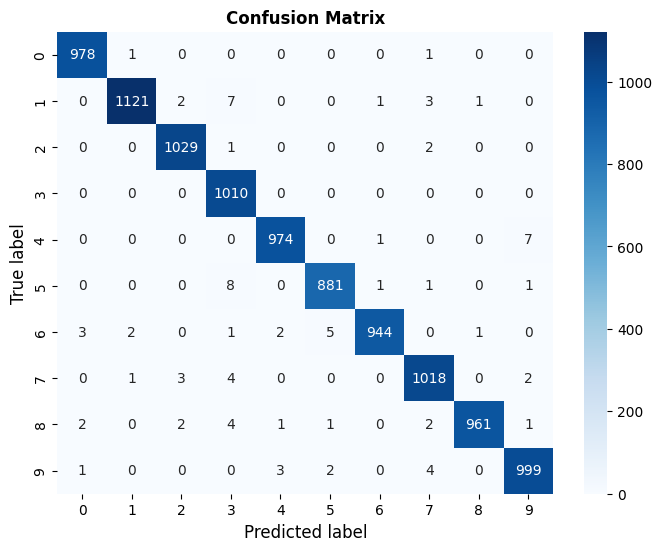

Total misclassified: 85


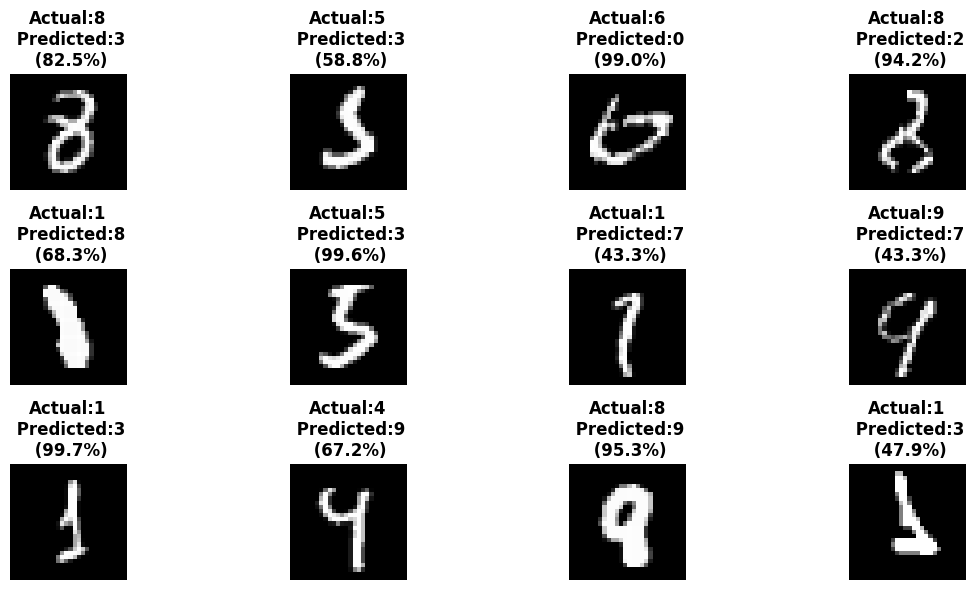

In [ ]:
# --- Evaluation block (add after model.fit) ---

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Basic test metrics
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# 2) Predictions
y_prob = model.predict(x_test, verbose=0)          # shape: (10000, 10)
y_pred = np.argmax(y_prob, axis=1)                 # predicted class ids
y_true = np.argmax(y_test, axis=1)                 # true class ids

# 3) Per-class metrics
print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4))

# 4) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# 5) Show a few wrong predictions
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)}")

n_show = 12
if len(wrong_idx) > 0:
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(wrong_idx[:n_show]):
        plt.subplot(3, 4, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
        conf = y_prob[idx, y_pred[idx]] * 100
        plt.title(f"Actual:{y_true[idx]}\n Predicted:{y_pred[idx]}\n ({conf:.1f}%)")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


Viewing Best Model

In [82]:
# Load Model Setting
loaded_model = keras.models.load_model("keras_model_best.keras")
loaded_model.summary()

c:\Enzo_Files\AIM Data Science\Capstone3 Projects\capstone_venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,446 (6.35 MB)

 Trainable params: 831,722 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 831,724 (3.17 MB)

Test loss: 0.0303
Test accuracy: 0.9922

Classification report:
              precision    recall  f1-score   support

           0     0.9909    0.9959    0.9934       980
           1     0.9930    1.0000    0.9965      1135
           2     0.9990    0.9855    0.9922      1032
           3     0.9960    0.9911    0.9935      1010
           4     0.9859    0.9969    0.9914       982
           5     0.9899    0.9933    0.9916       892
           6     0.9968    0.9906    0.9937       958
           7     0.9856    0.9961    0.9908      1028
           8     0.9918    0.9938    0.9928       974
           9     0.9930    0.9782    0.9855      1009

    accuracy                         0.9922     10000
   macro avg     0.9922    0.9921    0.9921     10000
weighted avg     0.9922    0.9922    0.9922     10000



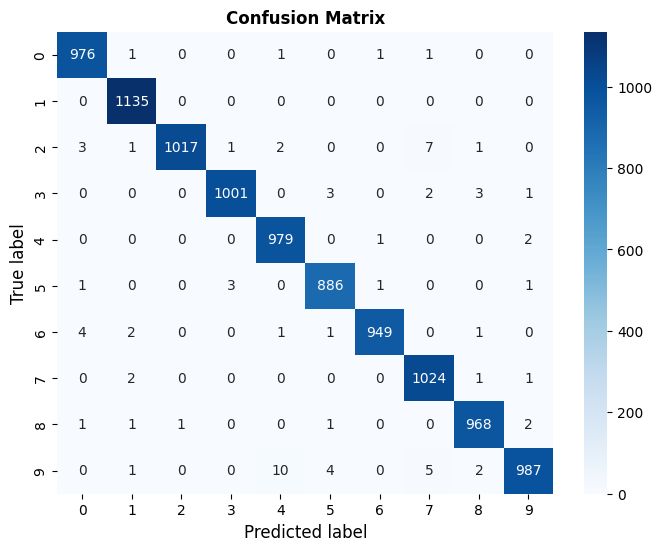

Total misclassified: 78


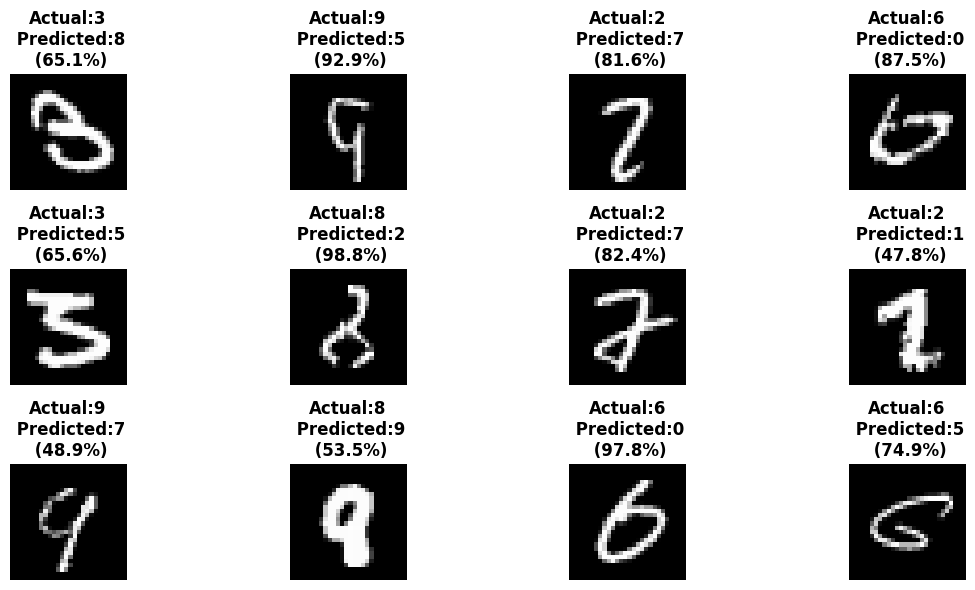

In [83]:
# --- Evaluation block (add after model.fit) ---

import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1) Basic test metrics
test_loss, test_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

# 2) Predictions
y_prob = loaded_model.predict(x_test, verbose=0)          # shape: (10000, 10)
y_pred = np.argmax(y_prob, axis=1)                 # predicted class ids
y_true = np.argmax(y_test, axis=1)                 # true class ids

# 3) Per-class metrics
print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4))

# 4) Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

# 5) Show a few wrong predictions
wrong_idx = np.where(y_pred != y_true)[0]
print(f"Total misclassified: {len(wrong_idx)}")

n_show = 12
if len(wrong_idx) > 0:
    plt.figure(figsize=(12, 6))
    for i, idx in enumerate(wrong_idx[:n_show]):
        plt.subplot(3, 4, i + 1)
        plt.imshow(x_test[idx].reshape(28, 28), cmap="gray")
        conf = y_prob[idx, y_pred[idx]] * 100
        plt.title(f"Actual:{y_true[idx]}\n Predicted:{y_pred[idx]}\n ({conf:.1f}%)")
        plt.axis("off")
    plt.tight_layout()
    plt.show()


## Task 3: Handwriting Test

In [84]:
# Load Model Setting
loaded_model = keras.models.load_model("keras_model_best.keras")
loaded_model.summary()

c:\Enzo_Files\AIM Data Science\Capstone3 Projects\capstone_venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       803,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,663,446 (6.35 MB)

 Trainable params: 831,722 (3.17 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 831,724 (3.17 MB)

In [ ]:
# If needed once:
# %pip install ipycanvas

import numpy as np
from PIL import Image
import io
import ipywidgets as widgets
# from IPython.display import display
from IPython.display import display, HTML
from ipycanvas import Canvas

# --- UI ---
# canvas = Canvas(width=280, height=280)
canvas = Canvas(width=280, height=280, sync_image_data=True)
output = widgets.Output()
btn_predict = widgets.Button(description="Predict", button_style="primary")
btn_clear = widgets.Button(description="Clear")

# --- drawing state ---
drawing = {"active": False}

def reset_canvas():
    canvas.fill_style = "black"
    canvas.fill_rect(0, 0, canvas.width, canvas.height)
    canvas.stroke_style = "white"
    canvas.line_width = 18
    canvas.line_cap = "round"
    canvas.line_join = "round"

reset_canvas()

def on_mouse_down(x, y):
    drawing["active"] = True
    canvas.begin_path()
    canvas.move_to(x, y)

def on_mouse_move(x, y):
    if not drawing["active"]:
        return
    canvas.line_to(x, y)
    canvas.stroke()

def on_mouse_up(x, y):
    drawing["active"] = False

canvas.on_mouse_down(on_mouse_down)
canvas.on_mouse_move(on_mouse_move)
canvas.on_mouse_up(on_mouse_up)

def on_clear(_):
    reset_canvas()
    with output:
        output.clear_output(wait=True)
        print("Canvas cleared.")

def on_predict(_):
    # RGBA array: (H, W, 4)
    rgba = np.array(canvas.get_image_data(0, 0, canvas.width, canvas.height), dtype=np.uint8)

    # white strokes on black bg -> use red channel as grayscale
    gray = rgba[:, :, 0]

    img = Image.fromarray(gray, mode="L").resize((28, 28), Image.LANCZOS)
    img_array = np.array(img).astype("float32") / 255.0
    img_array = np.expand_dims(img_array, axis=(0, -1))  # (1, 28, 28, 1)

    preds = loaded_model.predict(img_array, verbose=0)
    digit = int(np.argmax(preds[0]))
    confidence = float(preds[0][digit] * 100)

    with output:
        output.clear_output(wait=True)
        # print(f"Predicted digit: {digit} ({confidence:.1f}%)")
        display(HTML(f"<div style='font-size:32px; font-weight:700;'>Predicted digit: {digit} ({confidence:.1f}%)</div>"))


btn_clear.on_click(on_clear)
btn_predict.on_click(on_predict)

display(widgets.HBox([btn_clear, btn_predict]))

display(canvas)
display(output)


Canvas(height=280, sync_image_data=True, width=280)

Output()

## References

- Chollet, F., & Chollet, F. (2021). Deep learning with Python. simon and schuster.
- Bishop, C. M., & Bishop, H. (2023). Deep learning: Foundations and concepts. Springer Nature.
- Goodfellow, I., Bengio, Y., Courville, A., & Bengio, Y. (2016). Deep learning (Vol. 1, No. 2, pp. 1-800). Cambridge: MIT press.
- LeCun et al. (1989). Backpropagation Applied to Handwritten Zip Code Recognition. *Neural Computation* 1(4), pp. 541-551. doi: 10.1162/neco.1989.1.4.541.
- Monterola, CM. ML3 Notebook 2A.
- Simon, J. D. (2024). Understanding Deep Learning.

## Other Useful Resources

1. <a href="https://hannibunny.github.io/mlbook/neuralnetworks/03ConvolutionNeuralNetworks.html">Convolutional Neural Networks</a> by Johannes Maucher<br>
2. <a href="https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks">Stanford's CS230 CNN cheat sheet</a><br>
<br><b>ANIMATIONS</b><br>
- <a href="https://hannibunny.github.io/mlbook/neuralnetworks/convolutionDemos.html">Johannes Maucher's Convolution Demos</a>

<img src="images/banner-down.png" style="width: 100%;">